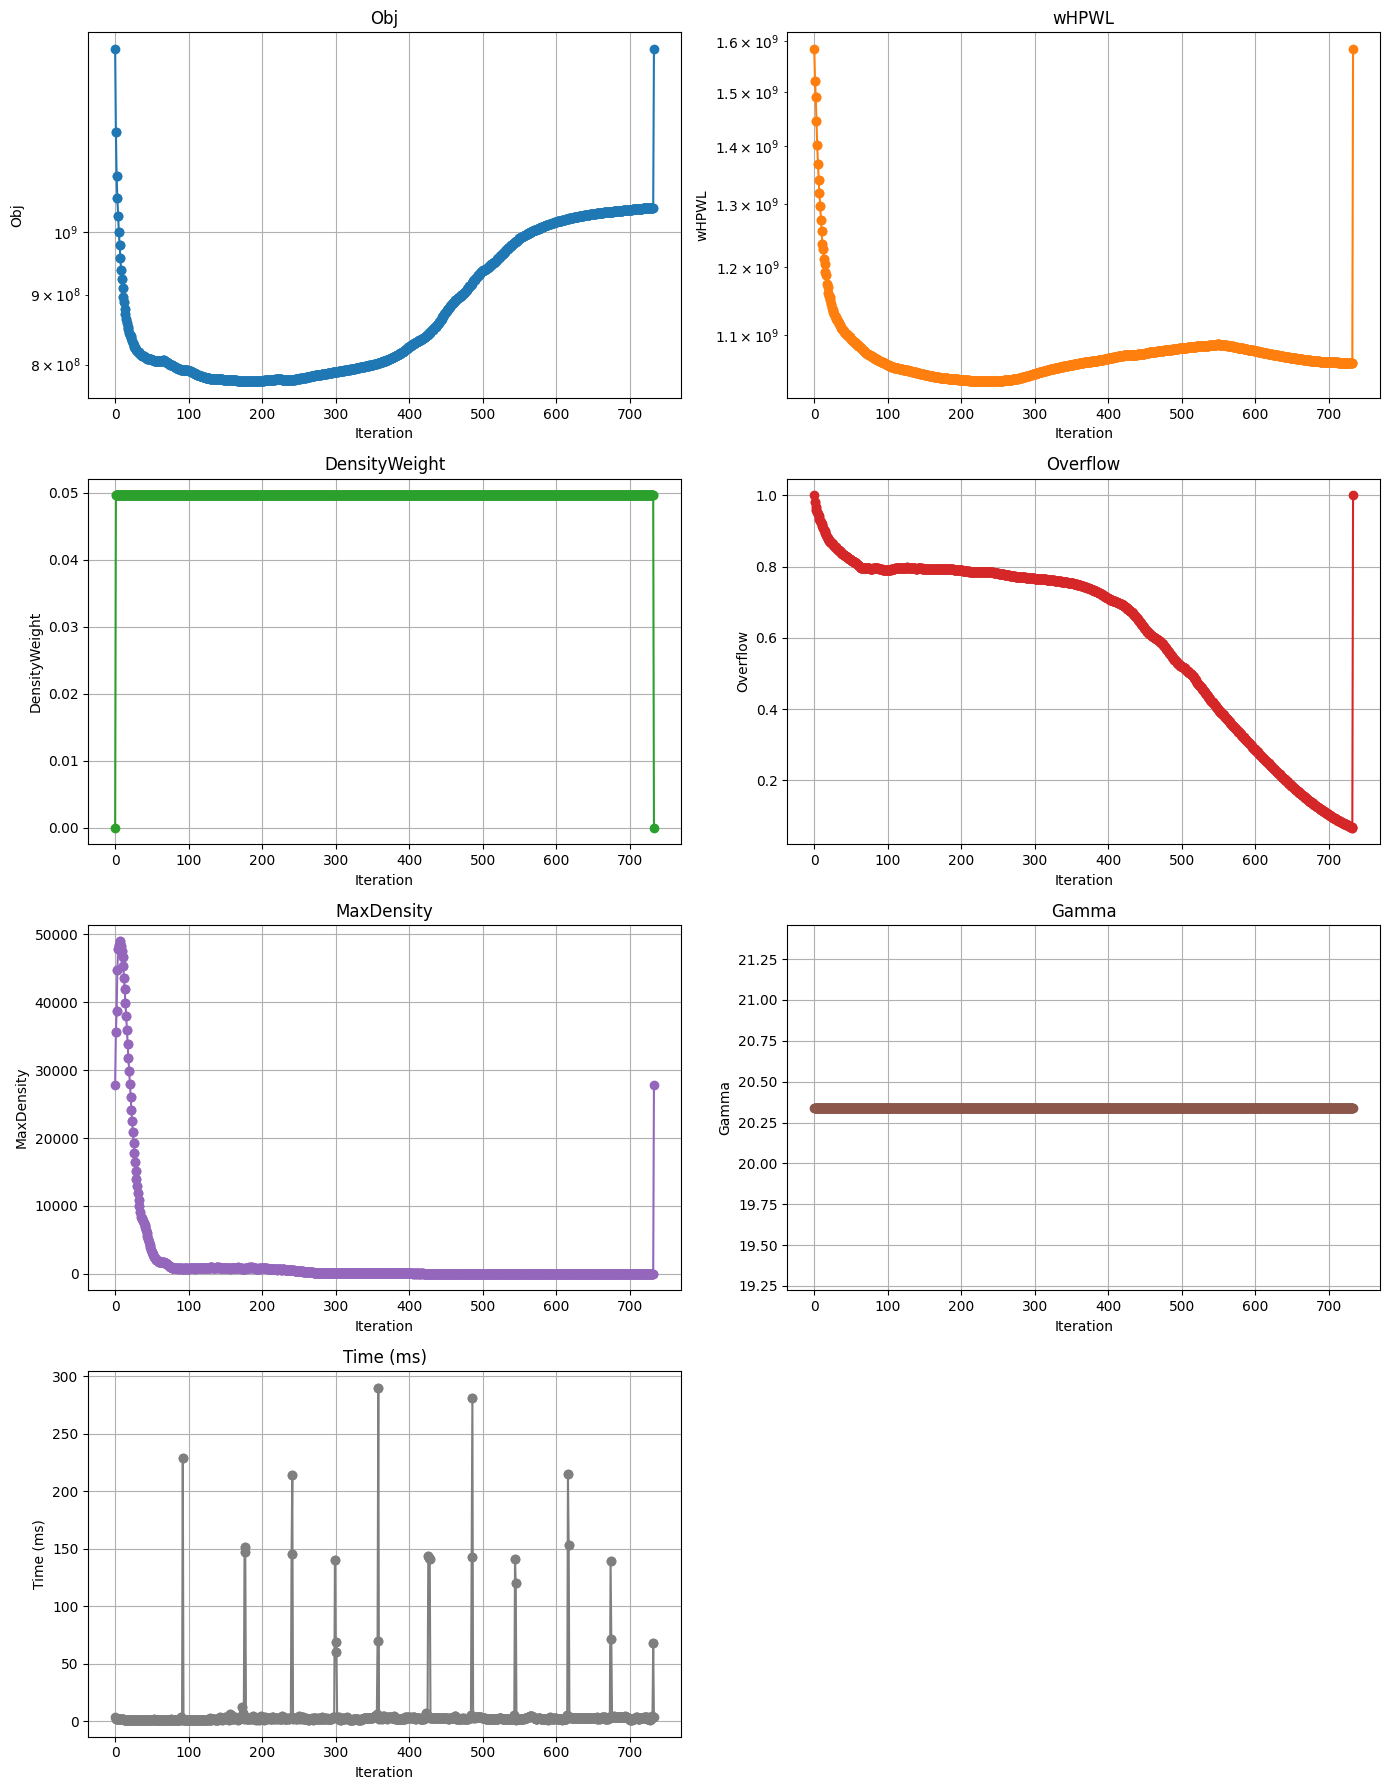

In [11]:
import re
import matplotlib.pyplot as plt

# 读取文件内容
file_path = "/home/xp/project/BBOPlace-Bench/src/placer/result.json"
with open(file_path, "r") as f:
    raw = f.read()

# 使用正则提取每次 iteration 的字段
pat = re.compile(
    r"iteration\s+(\d+).*?Obj\s+([+\-0-9.Ee]+).*?DensityWeight\s+([+\-0-9.Ee]+).*?wHPWL\s+([+\-0-9.Ee]+).*?Overflow\s+([+\-0-9.Ee]+).*?MaxDensity\s+([+\-0-9.Ee]+).*?gamma\s+([+\-0-9.Ee]+).*?time\s+([+\-0-9.Ee]+)ms",
    re.S,
)

records = []
for m in pat.finditer(raw):
    records.append({
        "iteration": int(m.group(1)),
        "Obj": float(m.group(2)),
        "DensityWeight": float(m.group(3)),
        "wHPWL": float(m.group(4)),
        "Overflow": float(m.group(5)),
        "MaxDensity": float(m.group(6)),
        "gamma": float(m.group(7)),
        "time_ms": float(m.group(8)),
    })

if not records:
    raise ValueError("No iteration records found in the file.")

# 按 iteration 排序（以防文件中顺序混乱）
records.sort(key=lambda r: r["iteration"])

iterations = [r["iteration"] for r in records]
objs = [r["Obj"] for r in records]
density_weights = [r["DensityWeight"] for r in records]
whpwls = [r["wHPWL"] for r in records]
overflows = [r["Overflow"] for r in records]
max_densities = [r["MaxDensity"] for r in records]
gammas = [r["gamma"] for r in records]
times = [r["time_ms"] for r in records]

# 每条曲线单独绘图
plt.figure(figsize=(14, 18))

plt.subplot(4, 2, 1)
plt.plot(iterations, objs, marker="o", color="tab:blue")
plt.title("Obj")
plt.xlabel("Iteration")
plt.ylabel("Obj")
plt.yscale("log")
plt.grid(True)

plt.subplot(4, 2, 2)
plt.plot(iterations, whpwls, marker="o", color="tab:orange")
plt.title("wHPWL")
plt.xlabel("Iteration")
plt.ylabel("wHPWL")
plt.yscale("log")
plt.grid(True)

plt.subplot(4, 2, 3)
plt.plot(iterations, density_weights, marker="o", color="tab:green")
plt.title("DensityWeight")
plt.xlabel("Iteration")
plt.ylabel("DensityWeight")
plt.grid(True)

plt.subplot(4, 2, 4)
plt.plot(iterations, overflows, marker="o", color="tab:red")
plt.title("Overflow")
plt.xlabel("Iteration")
plt.ylabel("Overflow")
plt.grid(True)

plt.subplot(4, 2, 5)
plt.plot(iterations, max_densities, marker="o", color="tab:purple")
plt.title("MaxDensity")
plt.xlabel("Iteration")
plt.ylabel("MaxDensity")
plt.grid(True)

plt.subplot(4, 2, 6)
plt.plot(iterations, gammas, marker="o", color="tab:brown")
plt.title("Gamma")
plt.xlabel("Iteration")
plt.ylabel("Gamma")
plt.grid(True)

plt.subplot(4, 2, 7)
plt.plot(iterations, times, marker="o", color="tab:gray")
plt.title("Time (ms)")
plt.xlabel("Iteration")
plt.ylabel("Time (ms)")
plt.grid(True)

# 空出右下角
plt.subplot(4, 2, 8).axis("off")

plt.tight_layout()
plt.show()
